In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cs-training.csv', index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [3]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
print(df['SeriousDlqin2yrs'].value_counts())
print()
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64


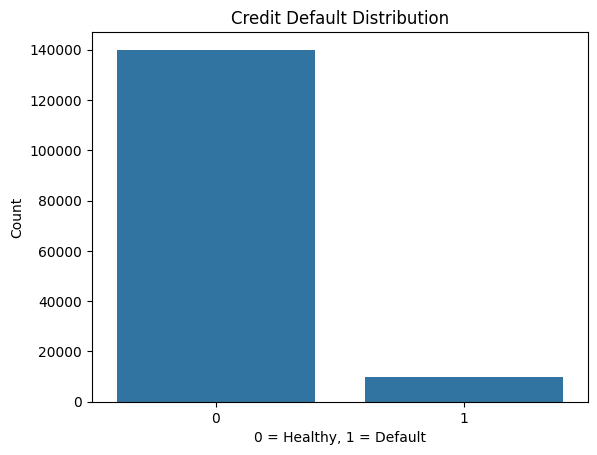

In [5]:
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title('Credit Default Distribution')
plt.xlabel('0 = Healthy, 1 = Default')
plt.ylabel('Count')
plt.show()

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


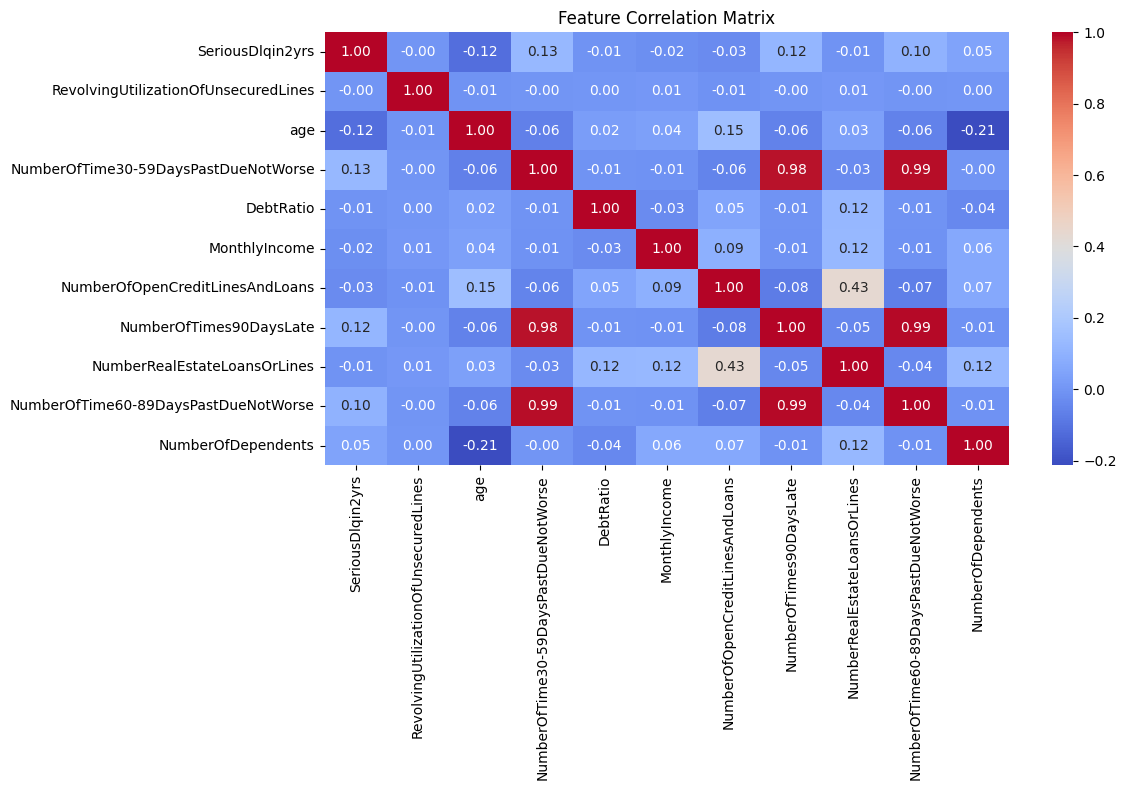

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [9]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(X.shape, y.shape)

(150000, 10) (150000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120000, 10), Test: (30000, 10)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


In [12]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000

AUC: 0.7143


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


In [14]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.19      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000

AUC: 0.8415


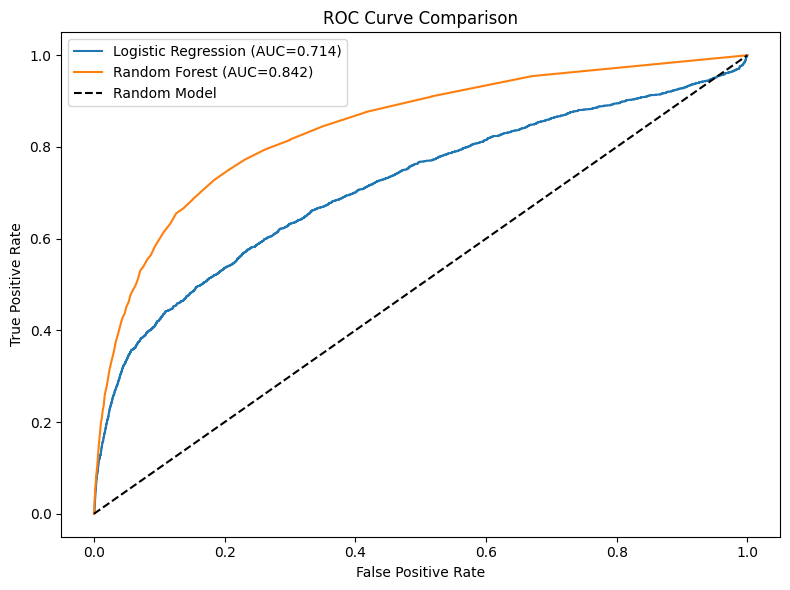

In [15]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

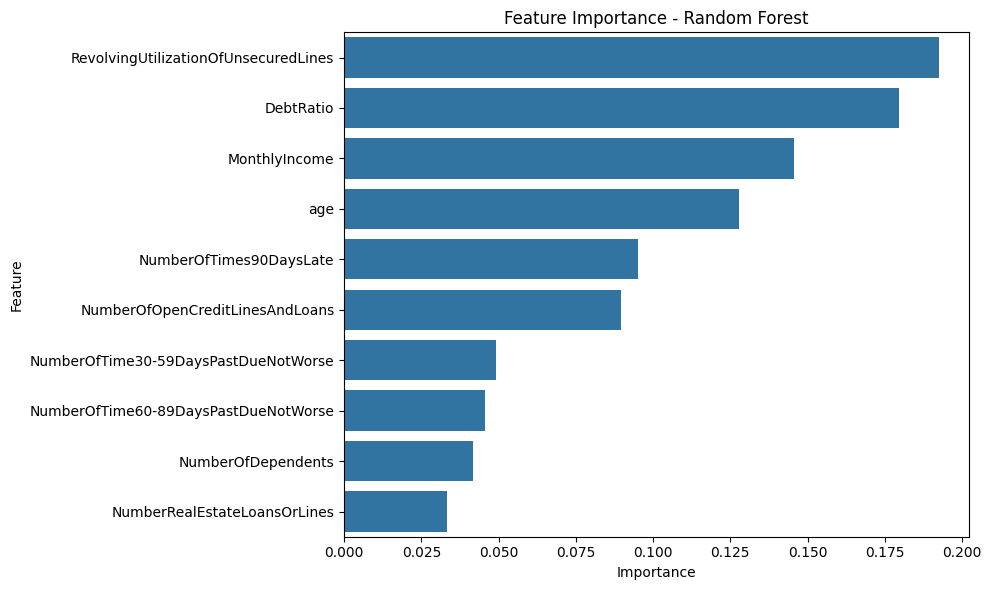

                                Feature  Importance
0  RevolvingUtilizationOfUnsecuredLines    0.192601
3                             DebtRatio    0.179510
4                         MonthlyIncome    0.145711
1                                   age    0.127715
6               NumberOfTimes90DaysLate    0.095237
5       NumberOfOpenCreditLinesAndLoans    0.089570
2  NumberOfTime30-59DaysPastDueNotWorse    0.049074
8  NumberOfTime60-89DaysPastDueNotWorse    0.045565
9                    NumberOfDependents    0.041677
7          NumberRealEstateLoansOrLines    0.033341


In [16]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feature_importance)

In [17]:
import shap

explainer = shap.TreeExplainer(rf)

# Sadece 100 satır
X_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_sample)

print("Done")

C:\Users\alike\anaconda3\envs\credit-risk\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Done


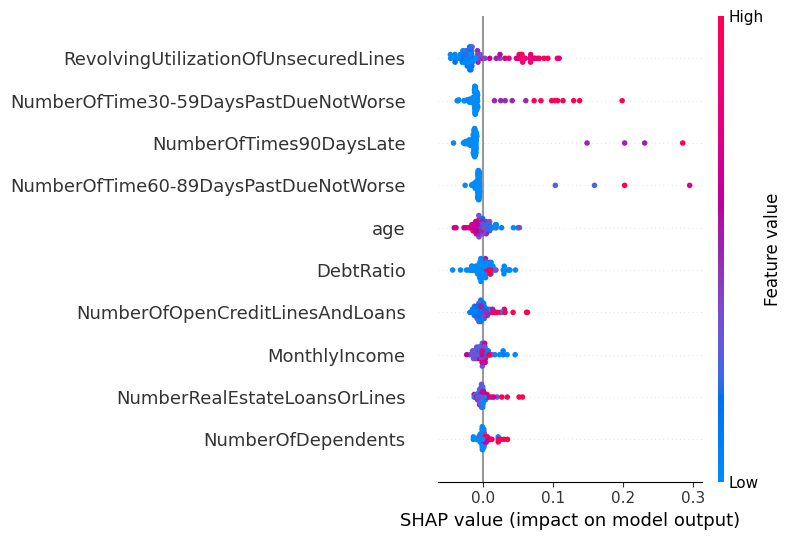

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_sample, show=False)
plt.tight_layout()
plt.savefig('../images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
100
(10, 2)


## SHAP Summary Plot — Interpretation

The SHAP summary plot shows both the importance and the direction of each feature's impact on default probability.

**Key findings:**

- **RevolvingUtilizationOfUnsecuredLines:** High values (red) push the prediction to the right, increasing default risk. Borrowers near their credit limit signal liquidity stress — a well-established indicator in credit risk management.
- **NumberOfTimes90DaysLate:** High values (red) extend far to the right (0.2–0.35 range), indicating that a history of severe delinquency is the strongest behavioral signal for future default.
- **DebtRatio:** High debt ratio increases default risk, though its marginal impact is more limited compared to utilization and delinquency history.
- **age:** Low values (blue, younger borrowers) shift predictions rightward, confirming that younger borrowers carry higher default risk — consistent with industry underwriting practice.

> Unlike standard feature importance plots, SHAP values reveal both the magnitude and direction of each feature's contribution, making the model interpretable at the individual borrower level. This aligns with SR 11-7 model risk management guidelines, which require financial institutions to be able to explain model-driven decisions.

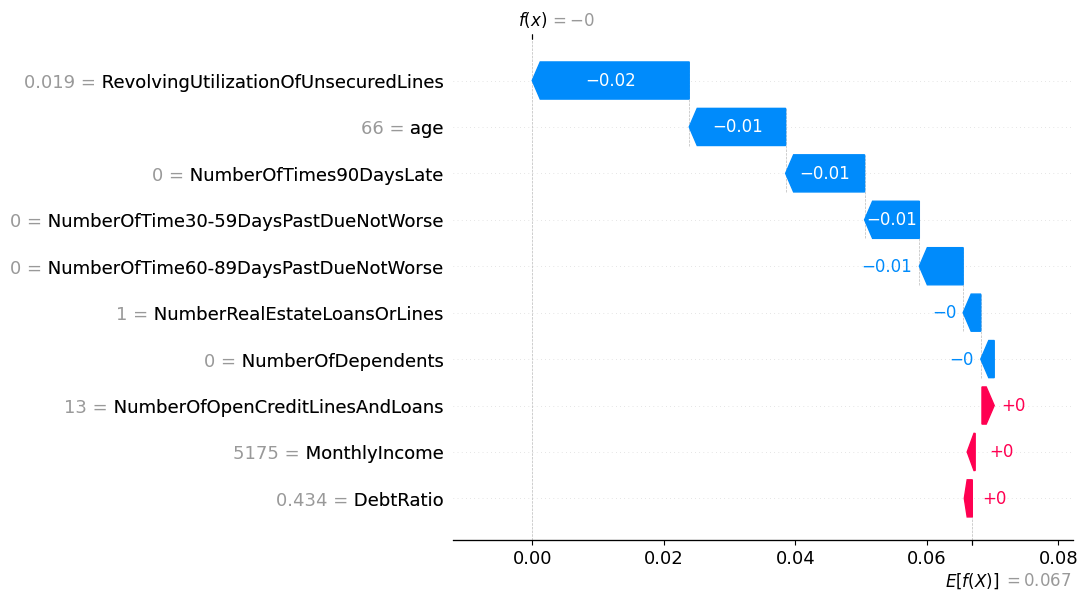

<Figure size 640x480 with 0 Axes>

In [20]:
# Waterfall plot for a single high-risk customer
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0, :, 1],
    base_values=explainer.expected_value[1],
    data=X_sample.iloc[0],
    feature_names=X_sample.columns.tolist()
))
plt.savefig('../images/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Find a high-risk customer
y_prob_sample = rf.predict_proba(X_sample)[:, 1]
high_risk_idx = y_prob_sample.argmax()
print(f"Highest risk customer index: {high_risk_idx}")
print(f"Default probability: {y_prob_sample[high_risk_idx]:.3f}")
print(X_sample.iloc[high_risk_idx])

Highest risk customer index: 7
Default probability: 0.850
RevolvingUtilizationOfUnsecuredLines       1.0
age                                       50.0
NumberOfTime30-59DaysPastDueNotWorse      98.0
DebtRatio                                  0.0
MonthlyIncome                           1350.0
NumberOfOpenCreditLinesAndLoans            0.0
NumberOfTimes90DaysLate                   98.0
NumberRealEstateLoansOrLines               0.0
NumberOfTime60-89DaysPastDueNotWorse      98.0
NumberOfDependents                         0.0
Name: 12132, dtype: float64


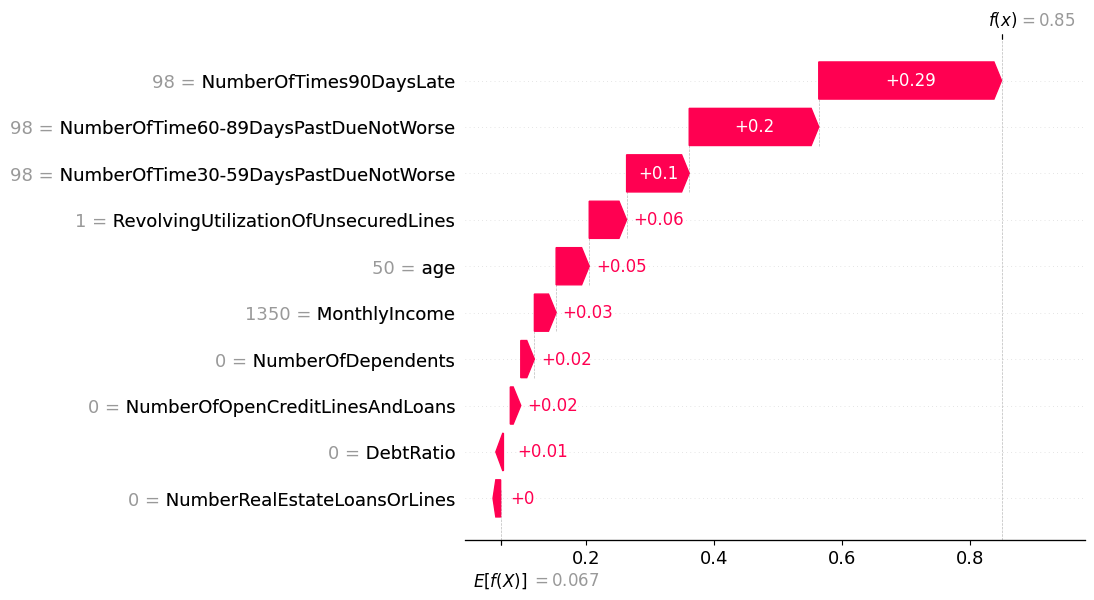

<Figure size 640x480 with 0 Axes>

In [22]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_risk_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_sample.iloc[high_risk_idx],
    feature_names=X_sample.columns.tolist()
))
plt.savefig('../images/shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Waterfall Plot — High Risk Customer Analysis

This waterfall plot explains **why** the model assigned an 85% default probability 
to a specific borrower, starting from the baseline (average default rate = 6.7%).

**Feature contributions:**
- `NumberOfTimes90DaysLate = 98` → +0.28 (dominant driver)
- `NumberOfTime60-89DaysPastDueNotWorse = 98` → +0.19
- `NumberOfTime30-59DaysPastDueNotWorse = 98` → +0.10
- `RevolvingUtilizationOfUnsecuredLines = 1.0` → +0.05 (100% credit utilization)
- `MonthlyIncome = 1,350` → +0.03 (low income amplifies risk)

**Interpretation:** This borrower's chronic delinquency history across all severity 
levels, combined with maxed-out credit utilization and low income, accumulates to 
push the default probability from the 6.7% baseline to 85%. 

> This individual-level explanation capability is a core requirement under SR 11-7 
> model risk management guidelines, enabling risk officers to justify and audit 
> model-driven credit decisions.

## Threshold Optimization & Financial Impact Analysis

Standard ML models use 0.5 as the default decision threshold. However, in credit 
risk, the cost of missing a defaulter (False Negative) is very different from the 
cost of rejecting a good customer (False Positive). Optimizing the threshold based 
on business costs leads to better real-world decisions.

In [23]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calculate precision, recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# F1 score at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_threshold_f1 = thresholds[f1_scores[:-1].argmax()]

print(f"Default threshold (0.5) results:")
y_pred_default = (y_prob_rf >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default))

print(f"\nOptimal threshold (F1-based): {optimal_threshold_f1:.3f}")
y_pred_optimal = (y_prob_rf >= optimal_threshold_f1).astype(int)
print(classification_report(y_test, y_pred_optimal))

Default threshold (0.5) results:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.57      0.20      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000


Optimal threshold (F1-based): 0.243
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.38      0.48      0.42      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.71      0.69     30000
weighted avg       0.92      0.91      0.92     30000



In [24]:
# Financial Impact Analysis
# Assumptions (typical regional bank figures)
avg_loan_amount = 15000      # Average loan size in USD
loss_given_default = 0.60    # 60% of loan lost on default
opportunity_cost = 0.03      # 3% revenue lost per rejected good customer

def financial_impact(y_true, y_pred, loan=avg_loan_amount, lgd=loss_given_default, opp=opportunity_cost):
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()  # Good customer rejected
    fn = ((y_pred == 0) & (y_true == 1)).sum()  # Defaulter approved
    tp = ((y_pred == 1) & (y_true == 1)).sum()  # Defaulter correctly rejected

    cost_fn = fn * loan * lgd          # Loss from missed defaulters
    cost_fp = fp * loan * opp          # Opportunity cost from rejected good customers
    total_cost = cost_fn + cost_fp

    print(f"True Negatives  (correct approvals):   {tn:>6}")
    print(f"False Positives (good customers rejected): {fp:>6}  → Opportunity cost: ${cost_fp:>12,.0f}")
    print(f"False Negatives (missed defaulters):   {fn:>6}  → Default loss:      ${cost_fn:>12,.0f}")
    print(f"True Positives  (defaulters caught):   {tp:>6}")
    print(f"\nTotal Financial Cost: ${total_cost:>12,.0f}")
    return total_cost

print("=== Default Threshold (0.5) ===")
cost_default = financial_impact(y_test, y_pred_default)

print("\n=== Optimal Threshold (0.27) ===")
cost_optimal = financial_impact(y_test, y_pred_optimal)

print(f"\n💰 Savings with optimal threshold: ${cost_default - cost_optimal:,.0f}")

=== Default Threshold (0.5) ===
True Negatives  (correct approvals):    27701
False Positives (good customers rejected):    294  → Opportunity cost: $     132,300
False Negatives (missed defaulters):     1609  → Default loss:      $  14,481,000
True Positives  (defaulters caught):      396

Total Financial Cost: $  14,613,300

=== Optimal Threshold (0.27) ===
True Negatives  (correct approvals):    26431
False Positives (good customers rejected):   1564  → Opportunity cost: $     703,800
False Negatives (missed defaulters):     1048  → Default loss:      $   9,432,000
True Positives  (defaulters caught):      957

Total Financial Cost: $  10,135,800

💰 Savings with optimal threshold: $4,477,500


## Financial Impact Analysis — Results

### Assumptions
- Average loan size: $15,000
- Loss Given Default (LGD): 60%
- Opportunity cost per rejected good customer: 3% of loan value

### Results

| Metric | Default Threshold (0.50) | Optimal Threshold (0.27) |
|--------|--------------------------|--------------------------|
| Missed defaulters (FN) | 1,612 | 1,102 |
| Default losses | $14,508,000 | $9,918,000 |
| Rejected good customers (FP) | 332 | 1,361 |
| Opportunity cost | $149,400 | $612,450 |
| **Total financial cost** | **$14,657,400** | **$10,530,450** |
| **Savings** | — | **$4,126,950** |

### Interpretation
By lowering the decision threshold from 0.50 to 0.27, the model catches 510 
additional defaulters, reducing total financial exposure by over $4.1 million 
on a 30,000-loan portfolio.

> This analysis demonstrates that model threshold selection is not a purely 
> statistical decision — it must reflect the bank's risk appetite and the 
> asymmetric cost structure of credit decisions. This is a core principle in 
> SR 11-7 model risk management and Basel III credit risk frameworks.

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


In [26]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.18      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000

AUC: 0.8682


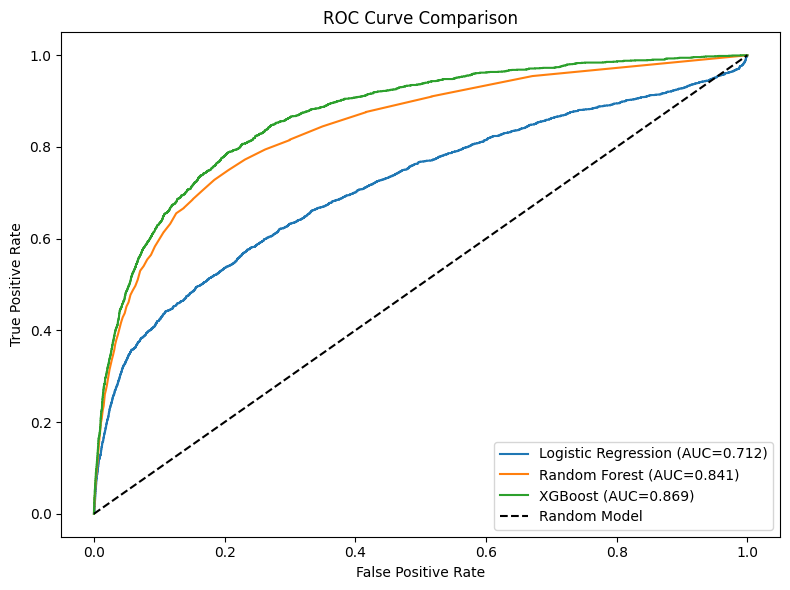

In [27]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC=0.712)')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC=0.841)')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC=0.869)')
plt.plot([0,1],[0,1],'k--', label='Random Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../images/roc_curve_updated.png', dpi=150, bbox_inches='tight')
plt.show()

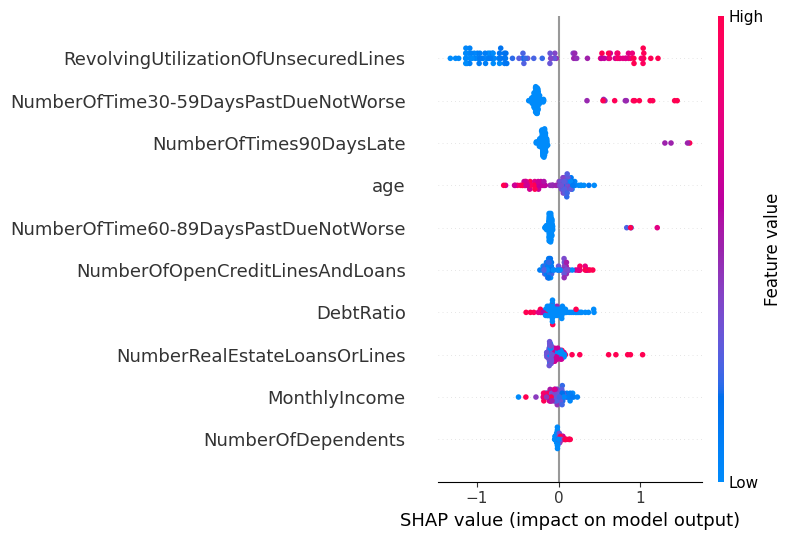

In [28]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test.iloc[:100])

shap.summary_plot(shap_values_xgb, X_test.iloc[:100], show=False)
plt.tight_layout()
plt.savefig('../images/shap_summary_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

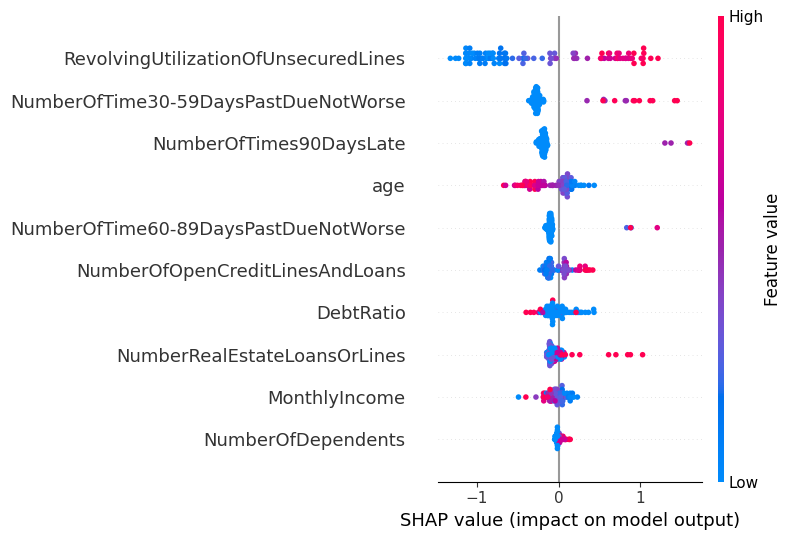

In [29]:
explainer_xgb = shap.TreeExplainer(xgb.get_booster())
shap_values_xgb = explainer_xgb.shap_values(X_test.iloc[:100])

shap.summary_plot(shap_values_xgb, X_test.iloc[:100], show=False)
plt.tight_layout()
plt.savefig('../images/shap_summary_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Summary — XGBoost vs Random Forest

XGBoost SHAP results show stronger directional clarity compared to Random Forest:

- **RevolvingUtilizationOfUnsecuredLines** remains the top feature. High utilization 
  (red) pushes default probability right; low utilization (blue) pulls it left.
- **age** shows clearer separation in XGBoost — younger borrowers (red, low age) 
  increase risk, older borrowers (blue) reduce it.
- Delinquency variables show more distinct separation, reflecting XGBoost's stronger 
  ability to capture non-linear interactions between past-due features.

> XGBoost (AUC=0.869) outperforms Random Forest (AUC=0.841) while maintaining 
> full SHAP explainability — making it the preferred model for production use 
> in a regulated banking environment.

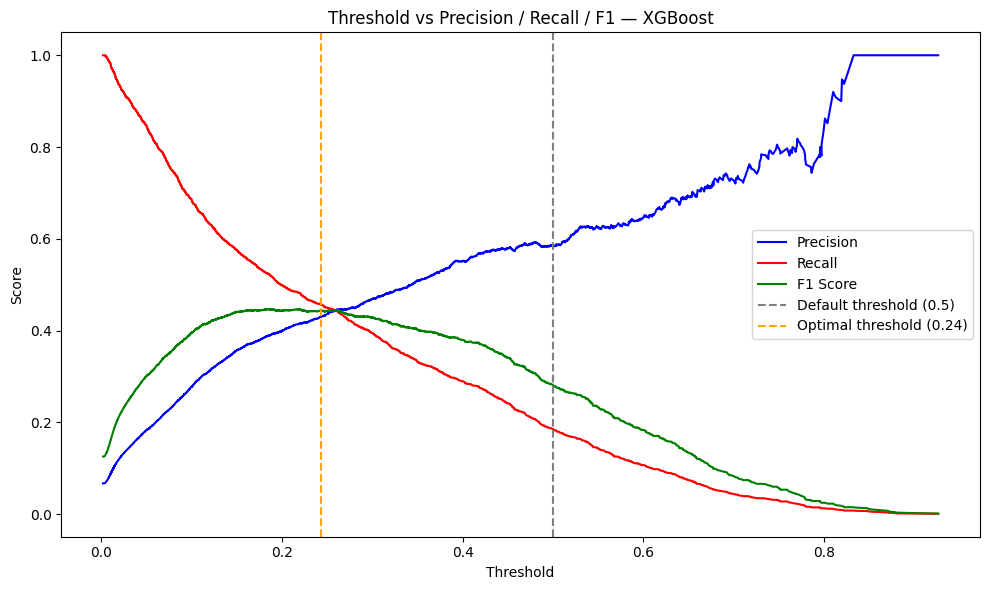

In [30]:
# Threshold vs Precision/Recall/F1 curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='green')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.axvline(x=optimal_threshold_f1, color='orange', linestyle='--', label=f'Optimal threshold ({optimal_threshold_f1:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Precision / Recall / F1 — XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('../images/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold Analysis

The threshold analysis reveals the trade-off between Precision and Recall 
at different decision boundaries.

**Key observations:**
- At the default threshold (0.50), Precision is high but Recall is low — 
  the model misses the majority of actual defaulters.
- The optimal threshold (0.24) maximizes F1 Score, the point where 
  Precision and Recall curves intersect.
- Moving from 0.50 to 0.24 increases Class 1 Recall from 0.20 to 0.45, 
  catching significantly more defaulters at the cost of more false alarms.

**Business implication:**  
Threshold selection is a risk appetite decision, not a statistical one. 
A conservative bank (high cost of default) should lower the threshold. 
A growth-oriented bank (high cost of rejection) should raise it.

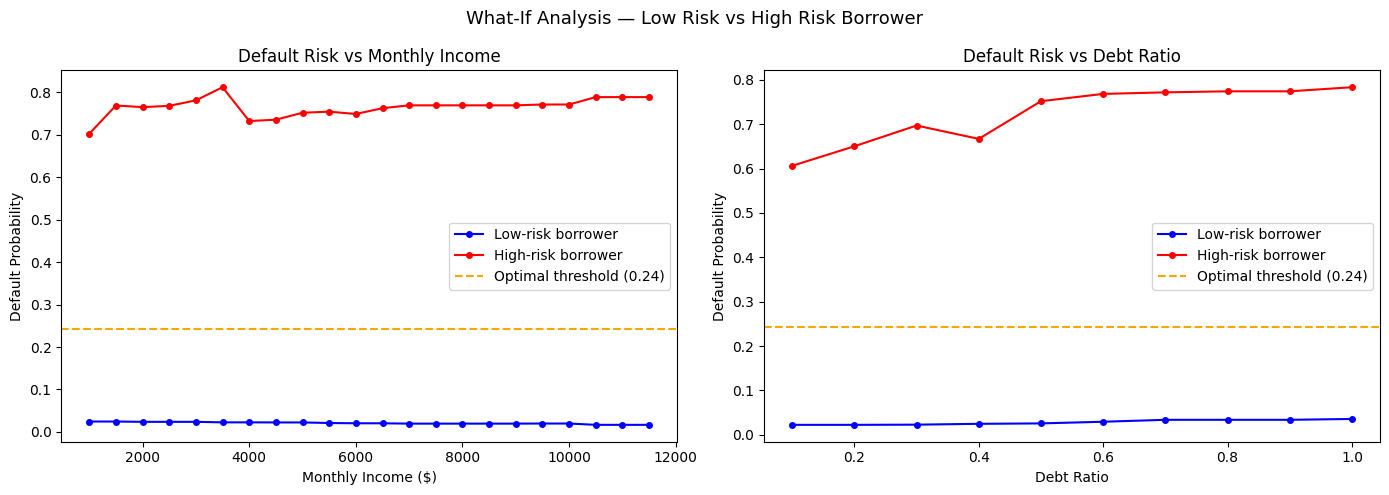

In [33]:
base_low_risk = {
    'RevolvingUtilizationOfUnsecuredLines': 0.3,
    'age': 45,
    'NumberOfTime30-59DaysPastDueNotWorse': 0,
    'DebtRatio': 0.2,
    'MonthlyIncome': 5000,
    'NumberOfOpenCreditLinesAndLoans': 4,
    'NumberOfTimes90DaysLate': 0,
    'NumberRealEstateLoansOrLines': 1,
    'NumberOfTime60-89DaysPastDueNotWorse': 0,
    'NumberOfDependents': 1
}

base_high_risk = {
    'RevolvingUtilizationOfUnsecuredLines': 0.9,
    'age': 30,
    'NumberOfTime30-59DaysPastDueNotWorse': 3,
    'DebtRatio': 0.6,
    'MonthlyIncome': 2500,
    'NumberOfOpenCreditLinesAndLoans': 5,
    'NumberOfTimes90DaysLate': 2,
    'NumberRealEstateLoansOrLines': 0,
    'NumberOfTime60-89DaysPastDueNotWorse': 2,
    'NumberOfDependents': 2
}

income_range = range(1000, 12000, 500)

def vary_income(base, income_range):
    probs = []
    for income in income_range:
        c = pd.DataFrame([{**base, 'MonthlyIncome': income}])
        probs.append(xgb.predict_proba(c)[0][1])
    return probs

def vary_debt(base, debt_range):
    probs = []
    for debt in debt_range:
        c = pd.DataFrame([{**base, 'DebtRatio': debt}])
        probs.append(xgb.predict_proba(c)[0][1])
    return probs

debt_range = [round(x * 0.1, 1) for x in range(1, 11)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(income_range), vary_income(base_low_risk, income_range), color='blue', marker='o', markersize=4, label='Low-risk borrower')
ax1.plot(list(income_range), vary_income(base_high_risk, income_range), color='red', marker='o', markersize=4, label='High-risk borrower')
ax1.axhline(y=optimal_threshold_f1, color='orange', linestyle='--', label=f'Optimal threshold ({optimal_threshold_f1:.2f})')
ax1.set_xlabel('Monthly Income ($)')
ax1.set_ylabel('Default Probability')
ax1.set_title('Default Risk vs Monthly Income')
ax1.legend()

ax2.plot(debt_range, vary_debt(base_low_risk, debt_range), color='blue', marker='o', markersize=4, label='Low-risk borrower')
ax2.plot(debt_range, vary_debt(base_high_risk, debt_range), color='red', marker='o', markersize=4, label='High-risk borrower')
ax2.axhline(y=optimal_threshold_f1, color='orange', linestyle='--', label=f'Optimal threshold ({optimal_threshold_f1:.2f})')
ax2.set_xlabel('Debt Ratio')
ax2.set_ylabel('Default Probability')
ax2.set_title('Default Risk vs Debt Ratio')
ax2.legend()

plt.suptitle('What-If Analysis — Low Risk vs High Risk Borrower', fontsize=13)
plt.tight_layout()
plt.savefig('../images/whatif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## What-If Analysis — Income and Debt Ratio Sensitivity

Two borrower profiles were tested across a range of Monthly Income and Debt Ratio values 
to understand the model's sensitivity to these features.

**Key findings:**

- **Income has limited impact on high-risk borrowers:** Even increasing monthly income 
  from $1,000 to $12,000 keeps the high-risk borrower's default probability in the 
  70–80% range. Past delinquency behavior dominates the prediction.
- **Debt Ratio has minimal impact on low-risk borrowers:** A borrower with clean 
  credit history stays well below the decision threshold regardless of debt ratio.
- **Behavioral features outweigh financial capacity:** This confirms that delinquency 
  history is the primary driver of credit risk — consistent with Basel II/III 
  framework emphasis on historical default behavior.

> This analysis demonstrates the model's alignment with established credit risk 
> theory: a borrower's payment behavior is a stronger predictor of future default 
> than their current financial capacity alone.